### MinCopter Plotting

Need to be able to plot the following

#### Sensor
For simulation, all @ 100Hz
- **Accelerometer** (3x float) body frame (in MinCopter, NED), in m/s2, after processing by MinCopter (AP_InertialSensor)
- **Gyrometer** (3x float) body frame (in MinCopter, NED), in rad/s, after processing by MinCopter (AP_InertialSensor)
- **Compass** (3x float) body frame (in MinCopter, NED), in $\micro T$, after processing by MinCopter (AP_Compass)
- **GPS** TODO Later
- **Barometer** TODO Later

#### State
Both estimated (from things like the EKF, and the complementary filter) and actual (from Gazebo)
- **Position (estimated)** (3x float) world frame (in MinCopter, NED), in metres
- **Position (actual)** (3x float) world frame (in MinCopter, NED), in metres
- **Velocity (estimated)** (3x float) world frame (in MinCopter, NED), in m/s
- **Velocity (actual)** (3x float) world frame (in MinCopter, NED), in m/s
- **Orientation (estimated)** (3x float) in Y-P-R intrinsic Euler Angles, each in radians
- **Orientation (actual)** (3x float) in Y-P-R intrinsic Euler Angles, each in radians
- **Angular Velocity (estimated)** *TODO what frame?*
- **Angular Velocity (actual)** *TODO what frame?*

#### Control
- **Force** (1x float) force applied in N
- **Torques** (3x float) angular forces required in Nm
- **Motor Velocities** (4x float) Output of mixer for each motor in rad/s

## `TODO`
- Change from range(0,len(... to actually having the simulation iteration or timestep
- Add ability to plot or retrieve certain ranges or subsets of the simulation (like from iteration 10-20)
  

In [1]:
from matplotlib import pyplot as plt
import struct
import math

## Configs
#max_iter = 125
max_iter = None

In [2]:
'''Read raw values'''
from parse import Parser
import random

parser = Parser()
mc_x, mc_y = parser.read_mincopter_log('../../build-generic/mincopter_log.txt')

for k in mc_y.keys():
    print(f"Found entry {k} with {len(mc_y[k])} readings")

Found entry roll with 1068 readings
Found entry pitch with 1068 readings
Found entry yaw with 1068 readings
Found entry er_x with 1068 readings
Found entry er_y with 1068 readings
Found entry er_z with 1068 readings
Found entry pos_x with 1068 readings
Found entry pos_y with 1068 readings
Found entry pos_z with 1068 readings
Found entry vel_x with 1068 readings
Found entry vel_y with 1068 readings
Found entry vel_z with 1068 readings
Found entry force with 1068 readings
Found entry rt with 1068 readings
Found entry pt with 1068 readings
Found entry yt with 1068 readings
Found entry m0 with 1068 readings
Found entry m1 with 1068 readings
Found entry m2 with 1068 readings
Found entry m3 with 1068 readings
Found entry accel_x with 1068 readings
Found entry accel_y with 1068 readings
Found entry accel_z with 1068 readings
Found entry gyro_x with 1068 readings
Found entry gyro_y with 1068 readings
Found entry gyro_z with 1068 readings
Found entry comp_x with 1068 readings
Found entry comp_y

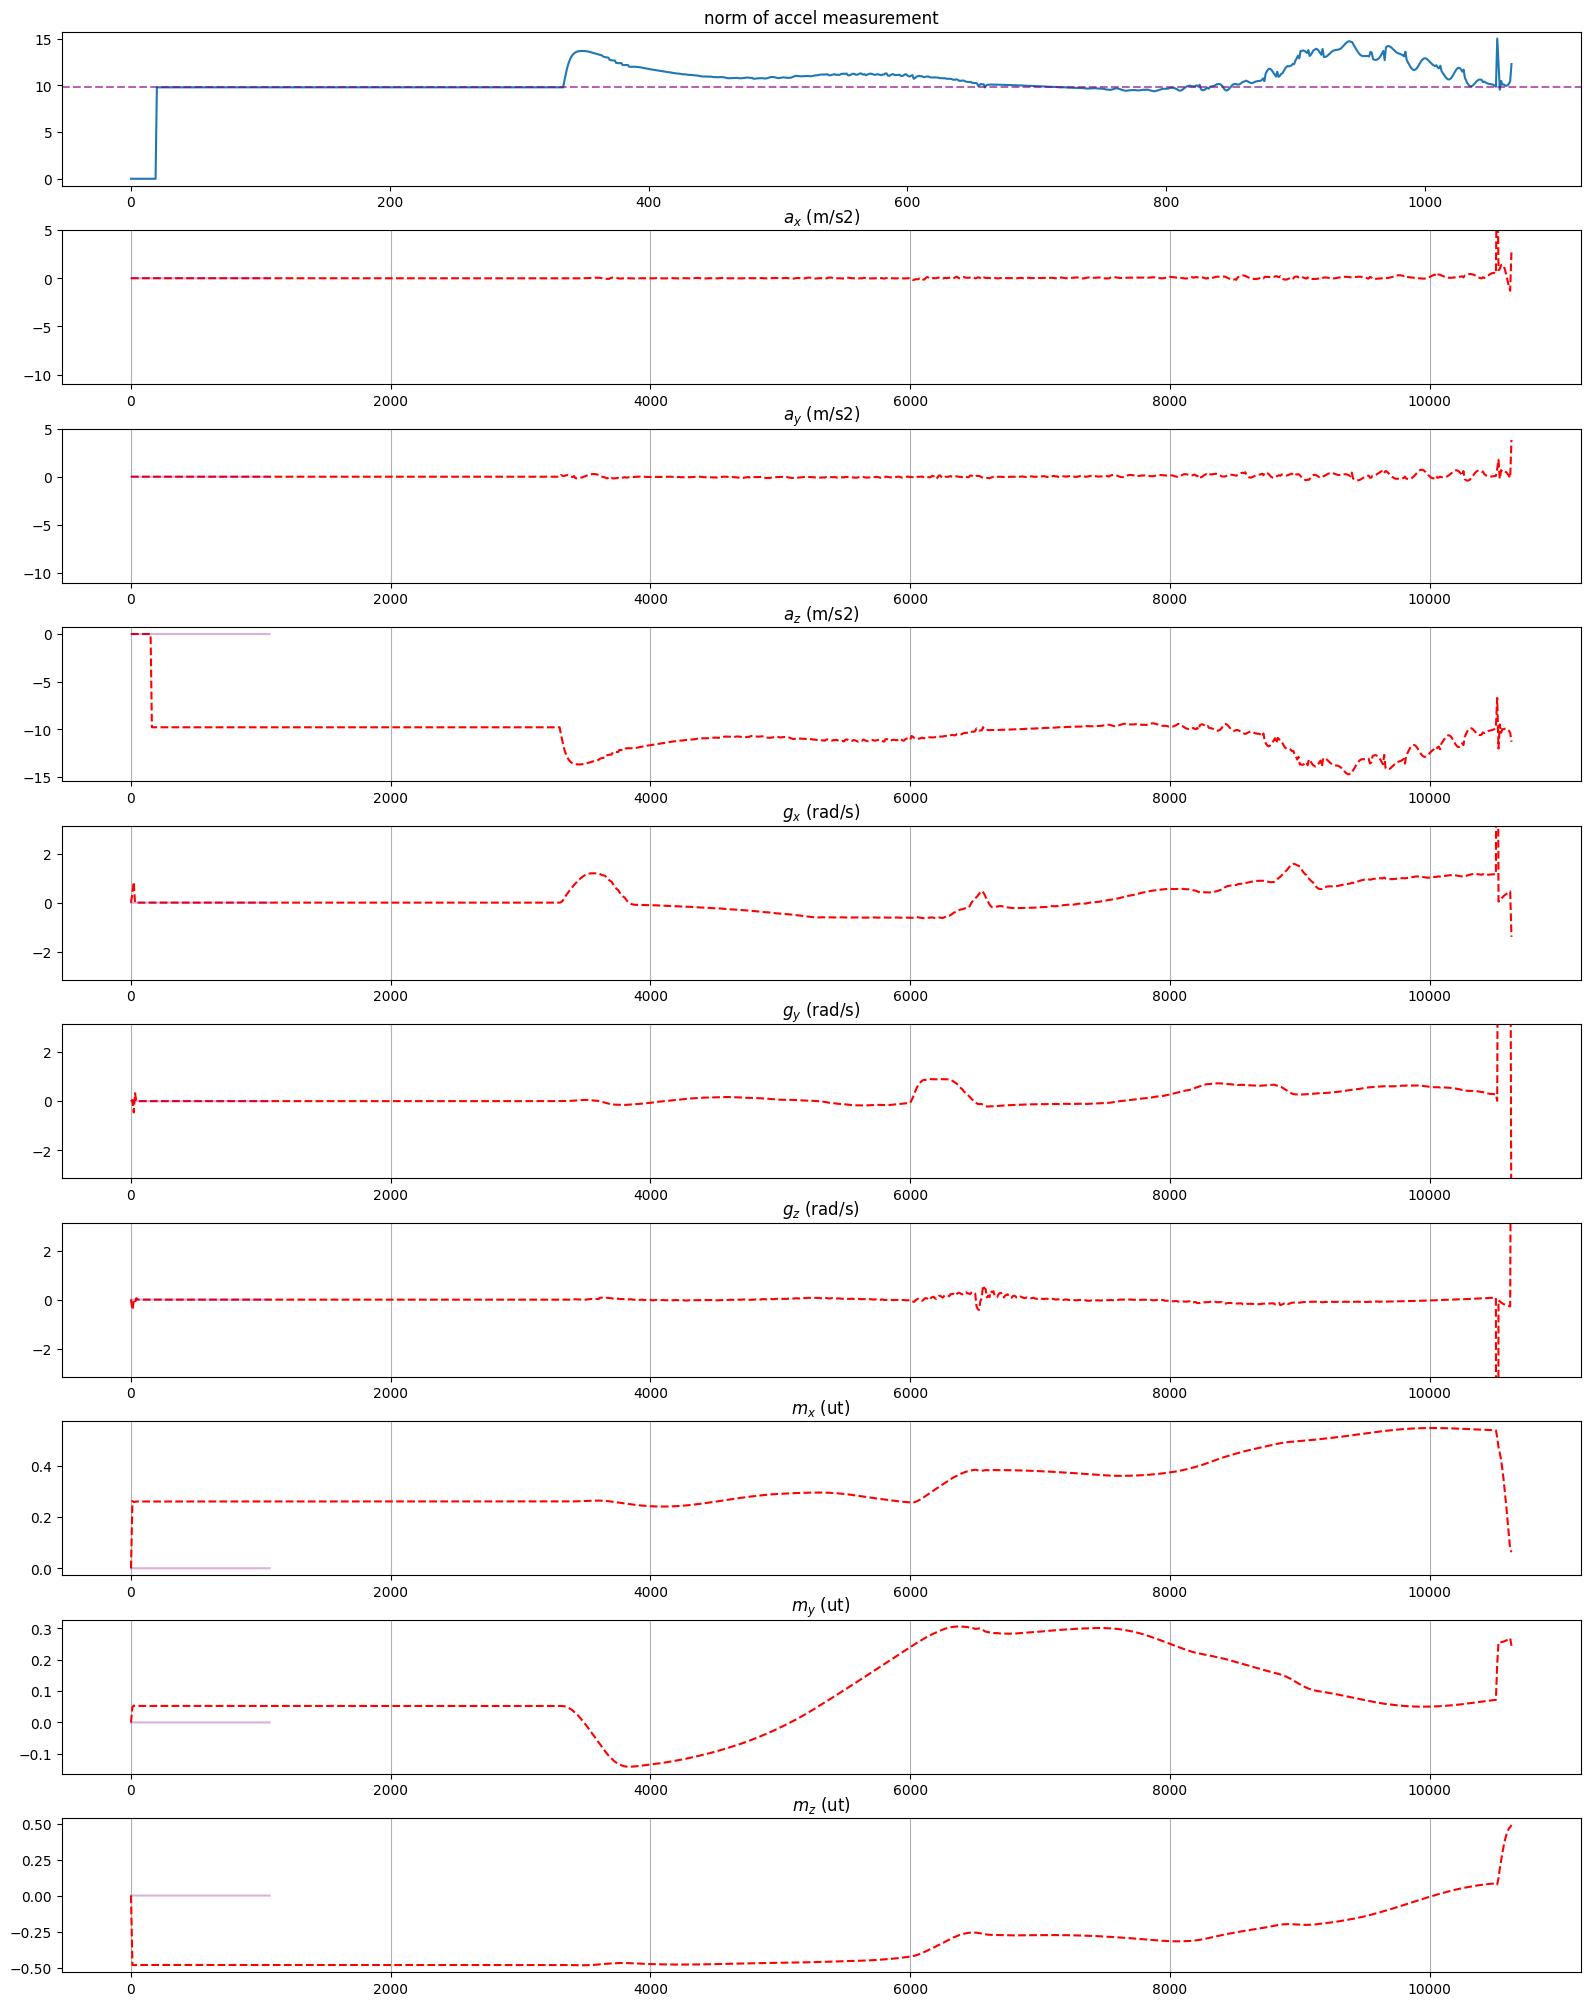

In [3]:
## Sensor Plots
sensor_fig, sensor_ax = plt.subplots(10,1, figsize=(16,20))
sensor_fig.tight_layout()

sensor_locs = {'accel_x': (1,0, r"$a_{x}$ (m/s2)"),
                   'accel_y': (2,0, r"$a_{y}$ (m/s2)"),
                   'accel_z': (3,0, r"$a_{z}$ (m/s2)"),
                   'gyro_x': (4,0, r"$g_{x}$ (rad/s)"),
                   'gyro_y': (5,0, r"$g_{y}$ (rad/s)"),
                   'gyro_z': (6,0, r"$g_{z}$ (rad/s)"),
                   'comp_x': (7,0, r"$m_{x}$ (ut)"),
                   'comp_y': (8,0, r"$m_{y}$ (ut)"),
                   'comp_z': (9,0, r"$m_{z}$ (ut)")
              }

for e in sensor_locs.keys():
    dlen = max_iter if max_iter is not None else len(mc_y[e])
    
    sensor_ax[sensor_locs[e][0]].set_title(sensor_locs[e][2])
    sensor_ax[sensor_locs[e][0]].plot(mc_x[e][:dlen], mc_y[e][:dlen], linestyle='--', color='red')
    sensor_ax[sensor_locs[e][0]].grid(axis='x')
    sensor_ax[sensor_locs[e][0]].plot(range(0,dlen), dlen*[0], linestyle='-', color='purple', alpha=0.3)
    
    if e in ['gyro_x', 'gyro_y', 'gyro_z']:
        sensor_ax[sensor_locs[e][0]].set_ylim(-math.pi, math.pi)

    if e in ['accel_x', 'accel_y']:
        sensor_ax[sensor_locs[e][0]].set_ylim(-11, 5)

sensor_ax[0].plot([math.sqrt(mc_y['accel_x'][i]**2 + mc_y['accel_y'][i]**2 + mc_y['accel_z'][i]**2) for i in range(0,len(mc_y['accel_x']))])
sensor_ax[0].axhline(y=9.8, linestyle='--', color='purple', alpha=0.6)
sensor_ax[0].set_title("norm of accel measurement")
plt.show()

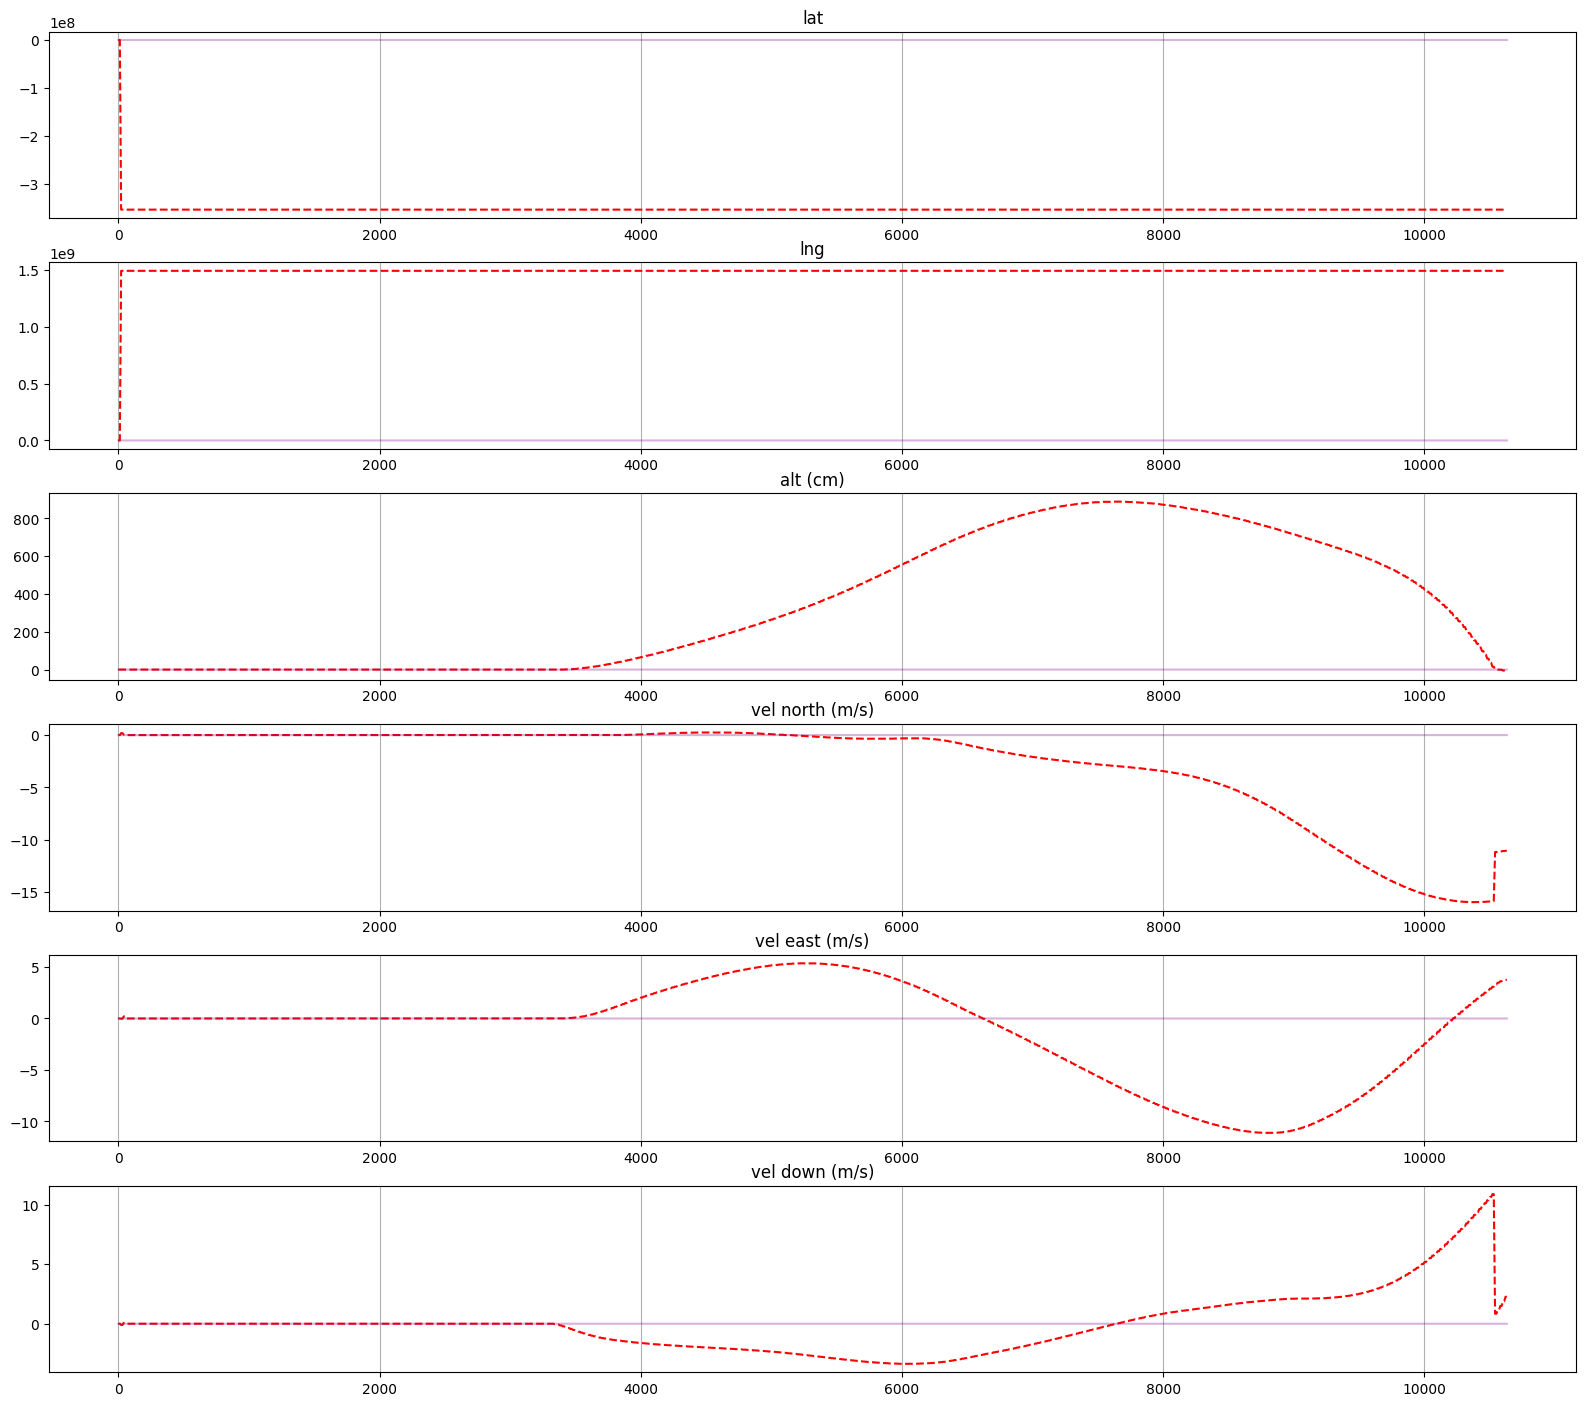

In [4]:
## GPS Plots
gps_fig, gps_ax = plt.subplots(6,1, figsize=(16,14))
gps_fig.tight_layout()

gps_locs = {'gps_lat': (0,0, r"lat"),
                   'gps_lng': (1,0, r"lng"),
                   'gps_alt_cm': (2,0, r"alt (cm)"),
                   'gps_vel_north': (3,0, r"vel north (m/s)"),
                   'gps_vel_east': (4,0, r"vel east (m/s)"),
                   'gps_vel_down': (5,0, r"vel down (m/s)")
              }

for e in gps_locs.keys():
    dlen = max_iter if max_iter is not None else len(mc_y[e])
    
    gps_ax[gps_locs[e][0]].set_title(gps_locs[e][2])
    gps_ax[gps_locs[e][0]].plot(mc_x[e][:dlen], mc_y[e][:dlen], linestyle='--', color='red')
    gps_ax[gps_locs[e][0]].grid(axis='x')
    gps_ax[gps_locs[e][0]].plot(mc_x[e][:dlen], dlen*[0], linestyle='-', color='purple', alpha=0.3)

plt.show()

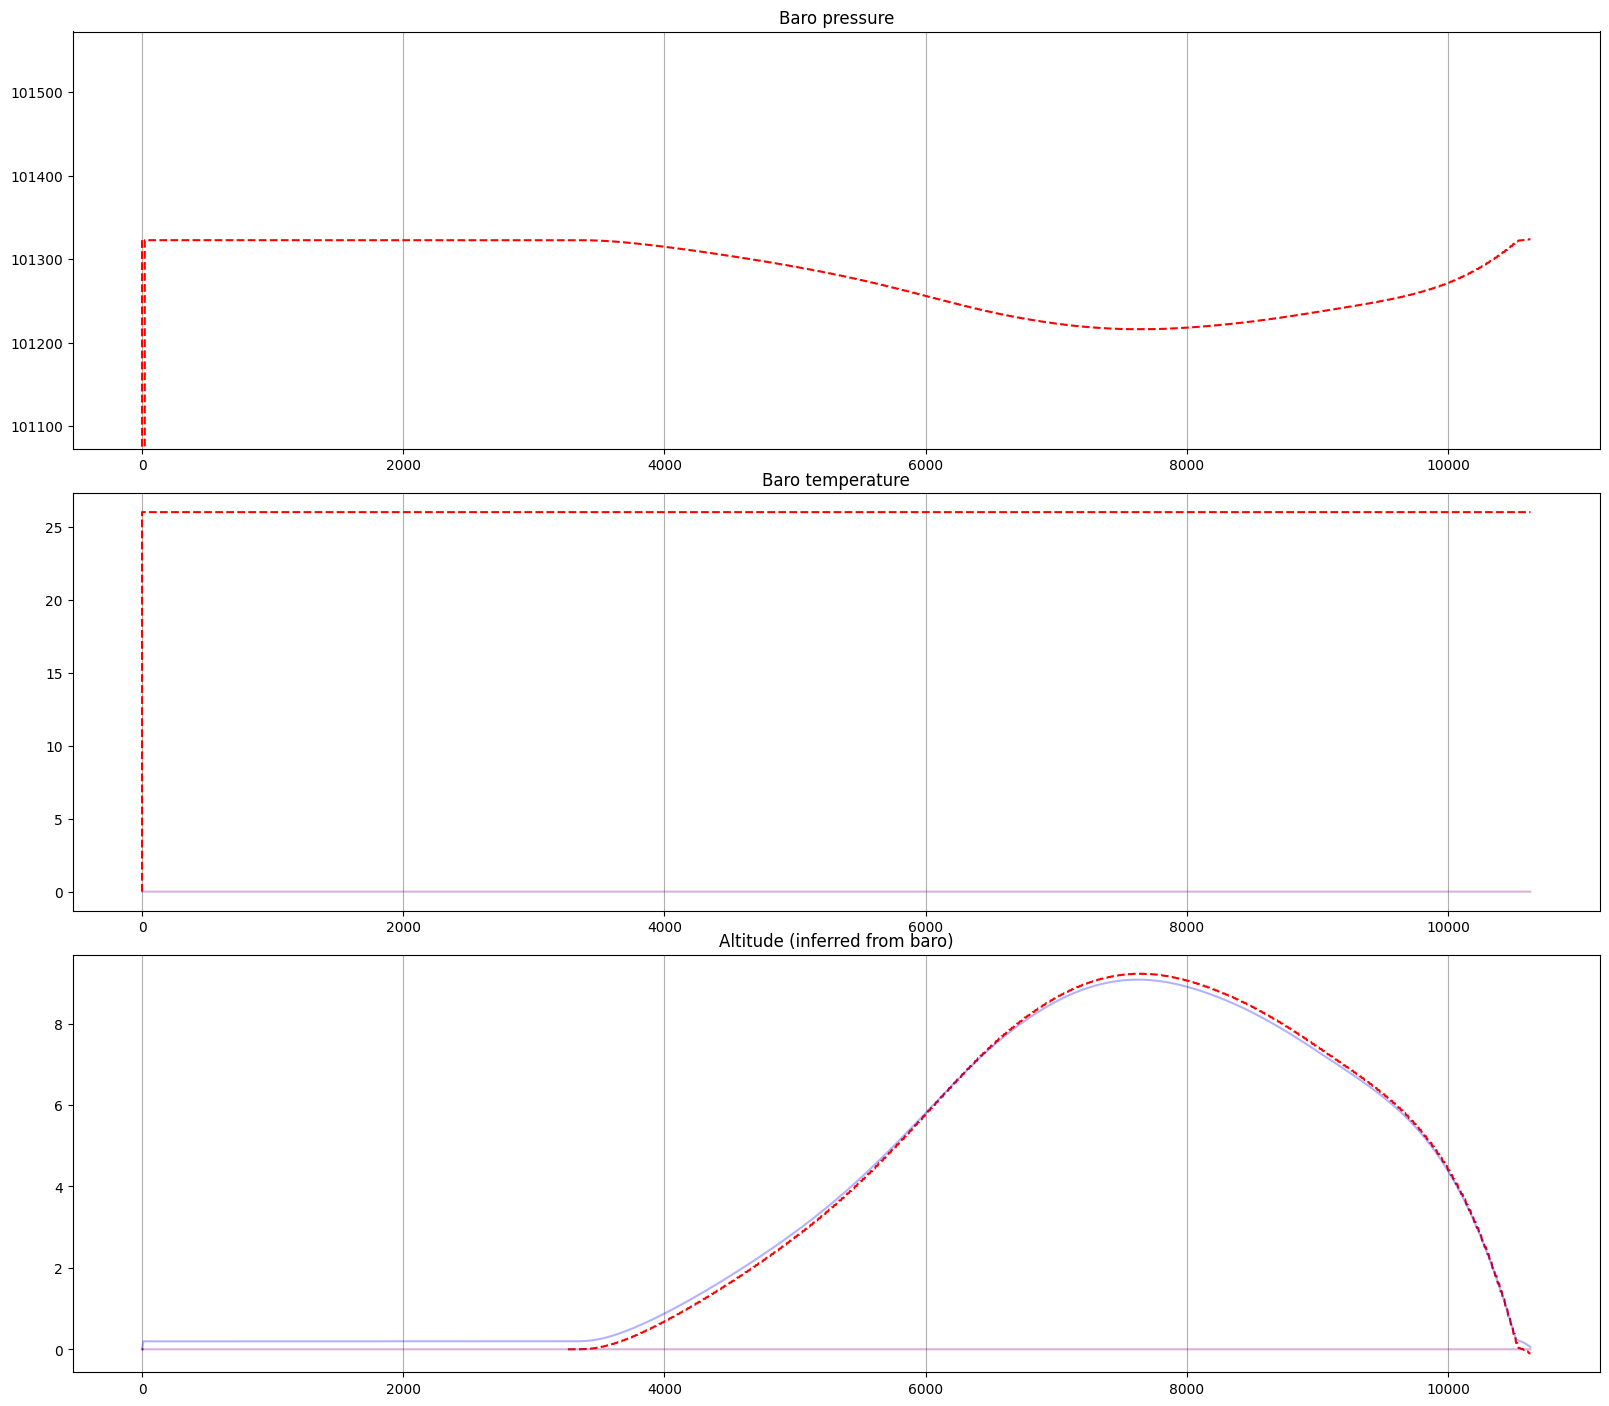

In [5]:
## Barometer plots
baro_fig, baro_ax = plt.subplots(3,1, figsize=(16,14))
baro_fig.tight_layout()

baro_ax[0].set_title('Baro pressure')
baro_ax[0].set_ylim(mc_y['baro_pressure'][0]-250, mc_y['baro_pressure'][0]+250)
baro_ax[0].plot(mc_x['baro_pressure'], mc_y['baro_pressure'], linestyle='--', color='red')
baro_ax[0].grid(axis='x')
baro_ax[0].plot(mc_x['baro_pressure'][:dlen], dlen*[0], linestyle='-', color='purple', alpha=0.3)

baro_ax[1].set_title('Baro temperature')
baro_ax[1].plot(mc_x['baro_temperature'], mc_y['baro_temperature'], linestyle='--', color='red')
baro_ax[1].grid(axis='x')
baro_ax[1].plot(mc_x['baro_temperature'][:dlen], dlen*[0], linestyle='-', color='purple', alpha=0.3)

baro_ax[2].set_title('Altitude (inferred from baro)')
baro_ax[2].plot(mc_x['baro_alt_inferred'], mc_y['baro_alt_inferred'], linestyle='--', color='red')
baro_ax[2].grid(axis='x')
baro_ax[2].plot(mc_x['baro_alt_inferred'][:dlen], dlen*[0], linestyle='-', color='purple', alpha=0.3)
baro_ax[2].plot(mc_x['pos_z_a'], [-1*e for e in mc_y['pos_z_a']], color='blue', label='actual z', alpha=0.3)
plt.show()

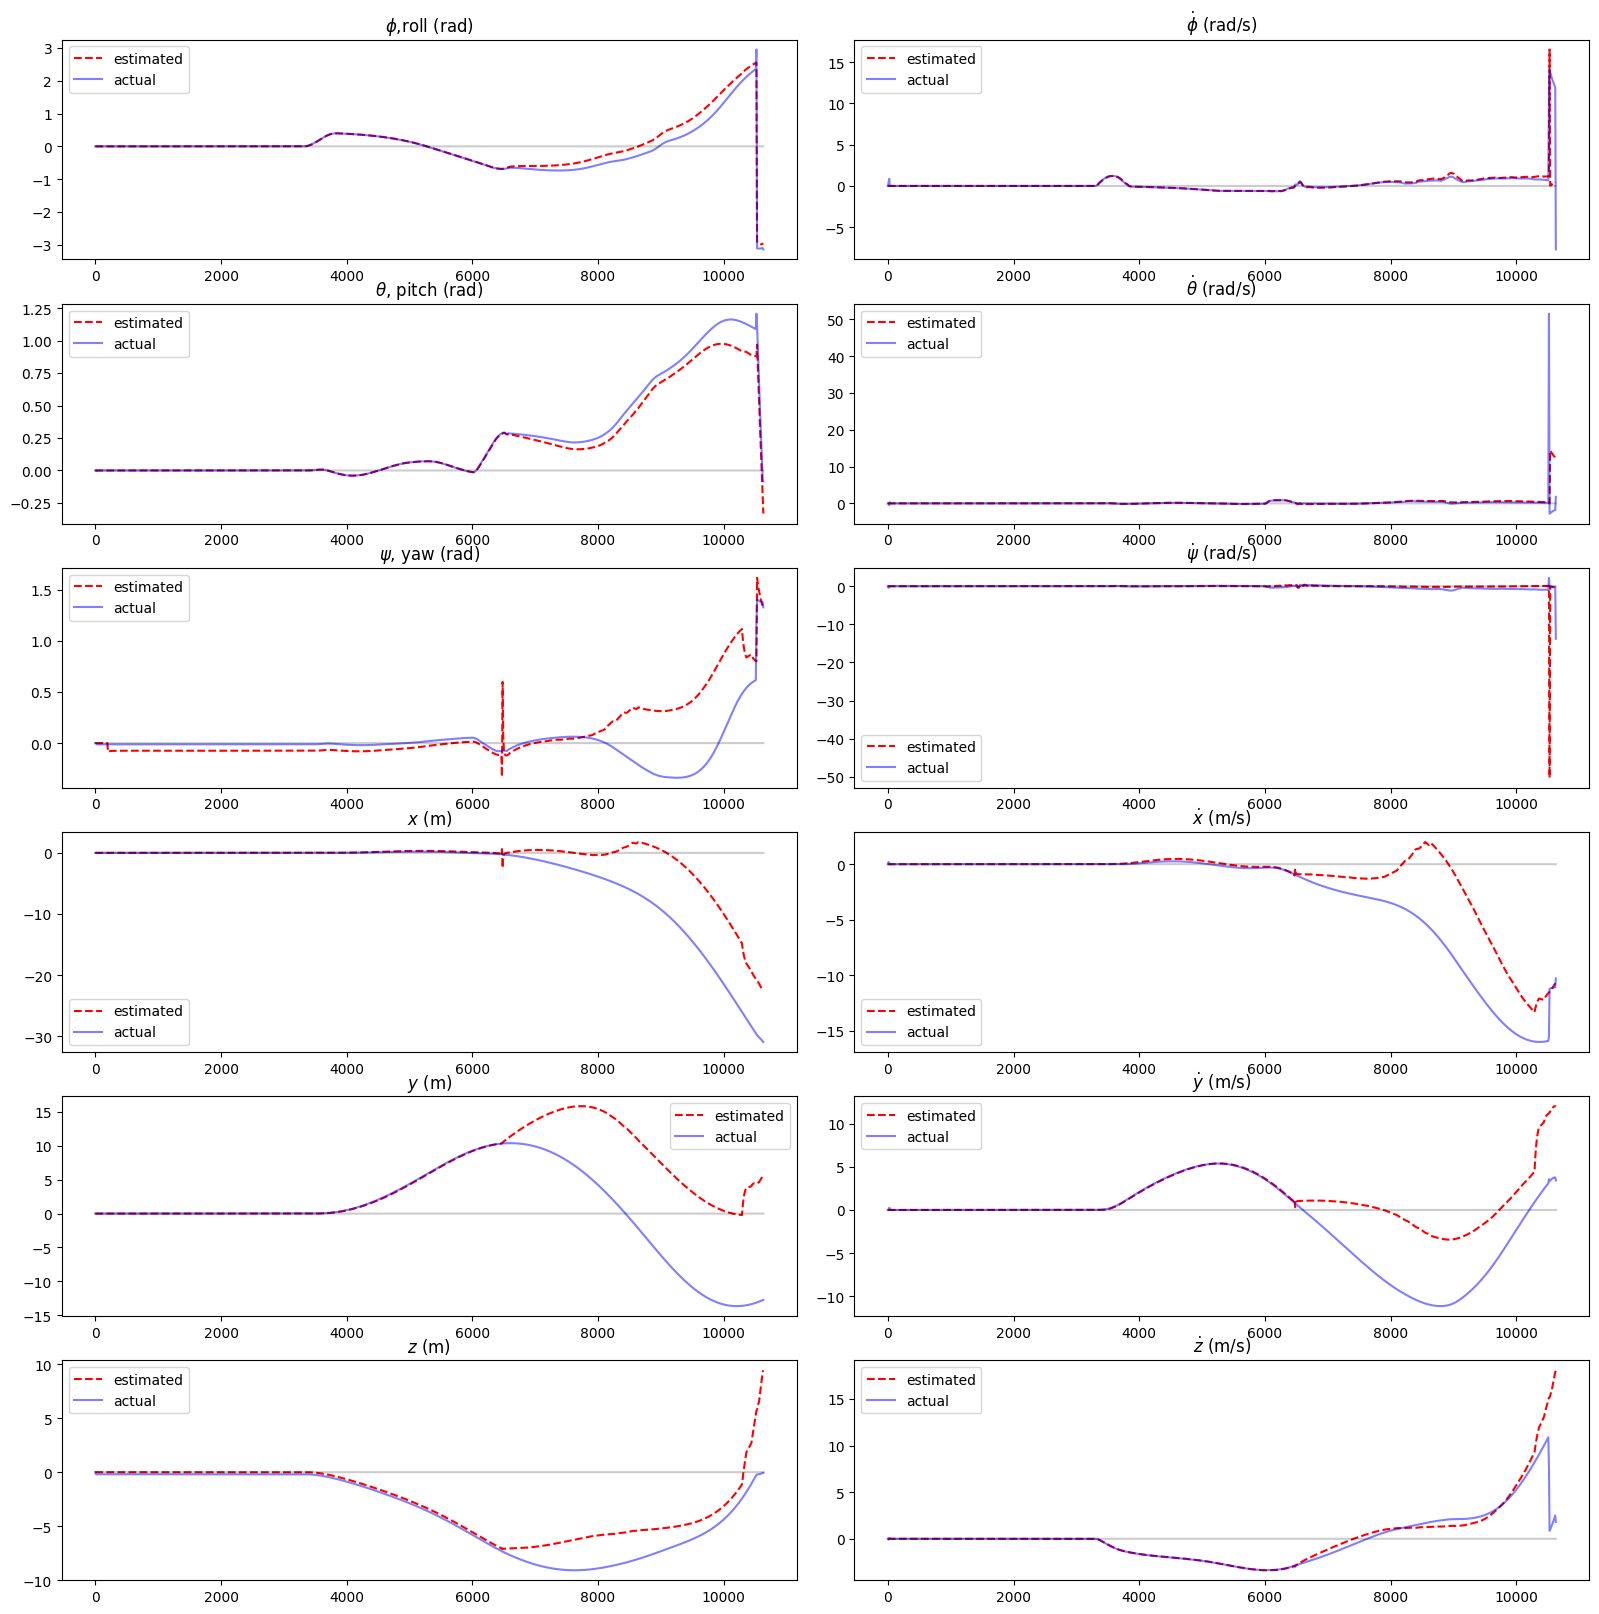

In [6]:
## State Plots
state_fig, state_ax = plt.subplots(6,2, figsize=(16,16))
state_fig.tight_layout()

state_locs = {'roll':  (0,0,r"$\phi$,roll (rad)", 'eul_x_a'),
              'pitch': (1,0,r"$\theta$, pitch (rad)", 'eul_y_a'),
              'yaw':   (2,0,r"$\psi$, yaw (rad)", 'eul_z_a'),
              'er_x':  (0,1,r"$\dot{\phi}$ (rad/s)", 'er_x_a'),
              'er_y':  (1,1,r"$\dot{\theta}$ (rad/s)", 'er_y_a'),
              'er_z':  (2,1,r"$\dot{\psi}$ (rad/s)", 'er_z_a'),
              'pos_x': (3,0,r"$x$ (m)", 'pos_x_a'),
              'pos_y': (4,0,r"$y$ (m)", 'pos_y_a'),
              'pos_z': (5,0,r"$z$ (m)", 'pos_z_a'),
              'vel_x': (3,1,r"$\dot{x}$ (m/s)", 'vel_x_a'),
              'vel_y': (4,1,r"$\dot{y}$ (m/s)", 'vel_y_a'),
              'vel_z': (5,1,r"$\dot{z}$ (m/s)", 'vel_z_a')
             }

for e in state_locs.keys():
    dlen = max_iter if max_iter is not None else len(mc_y[e])

    state_ax[state_locs[e][0], state_locs[e][1]].set_title(state_locs[e][2])
    state_ax[state_locs[e][0], state_locs[e][1]].plot(mc_x[e][:dlen], mc_y[e][:dlen], linestyle='--', color='red', label='estimated')
    if state_locs[e][3] is not None:
        state_ax[state_locs[e][0], state_locs[e][1]].plot(mc_x[state_locs[e][3]][:dlen], mc_y[state_locs[e][3]][:dlen], linestyle='-', color='blue', alpha=0.5, label='actual')
        
    if e in ['roll','pitch','yaw']:
        ## TODO Set limits and add lines at each 90deg interval
        pass
    state_ax[state_locs[e][0], state_locs[e][1]].plot(mc_x[e][:dlen], dlen*[0], color='black', alpha=0.2)
    state_ax[state_locs[e][0], state_locs[e][1]].legend()

plt.show()

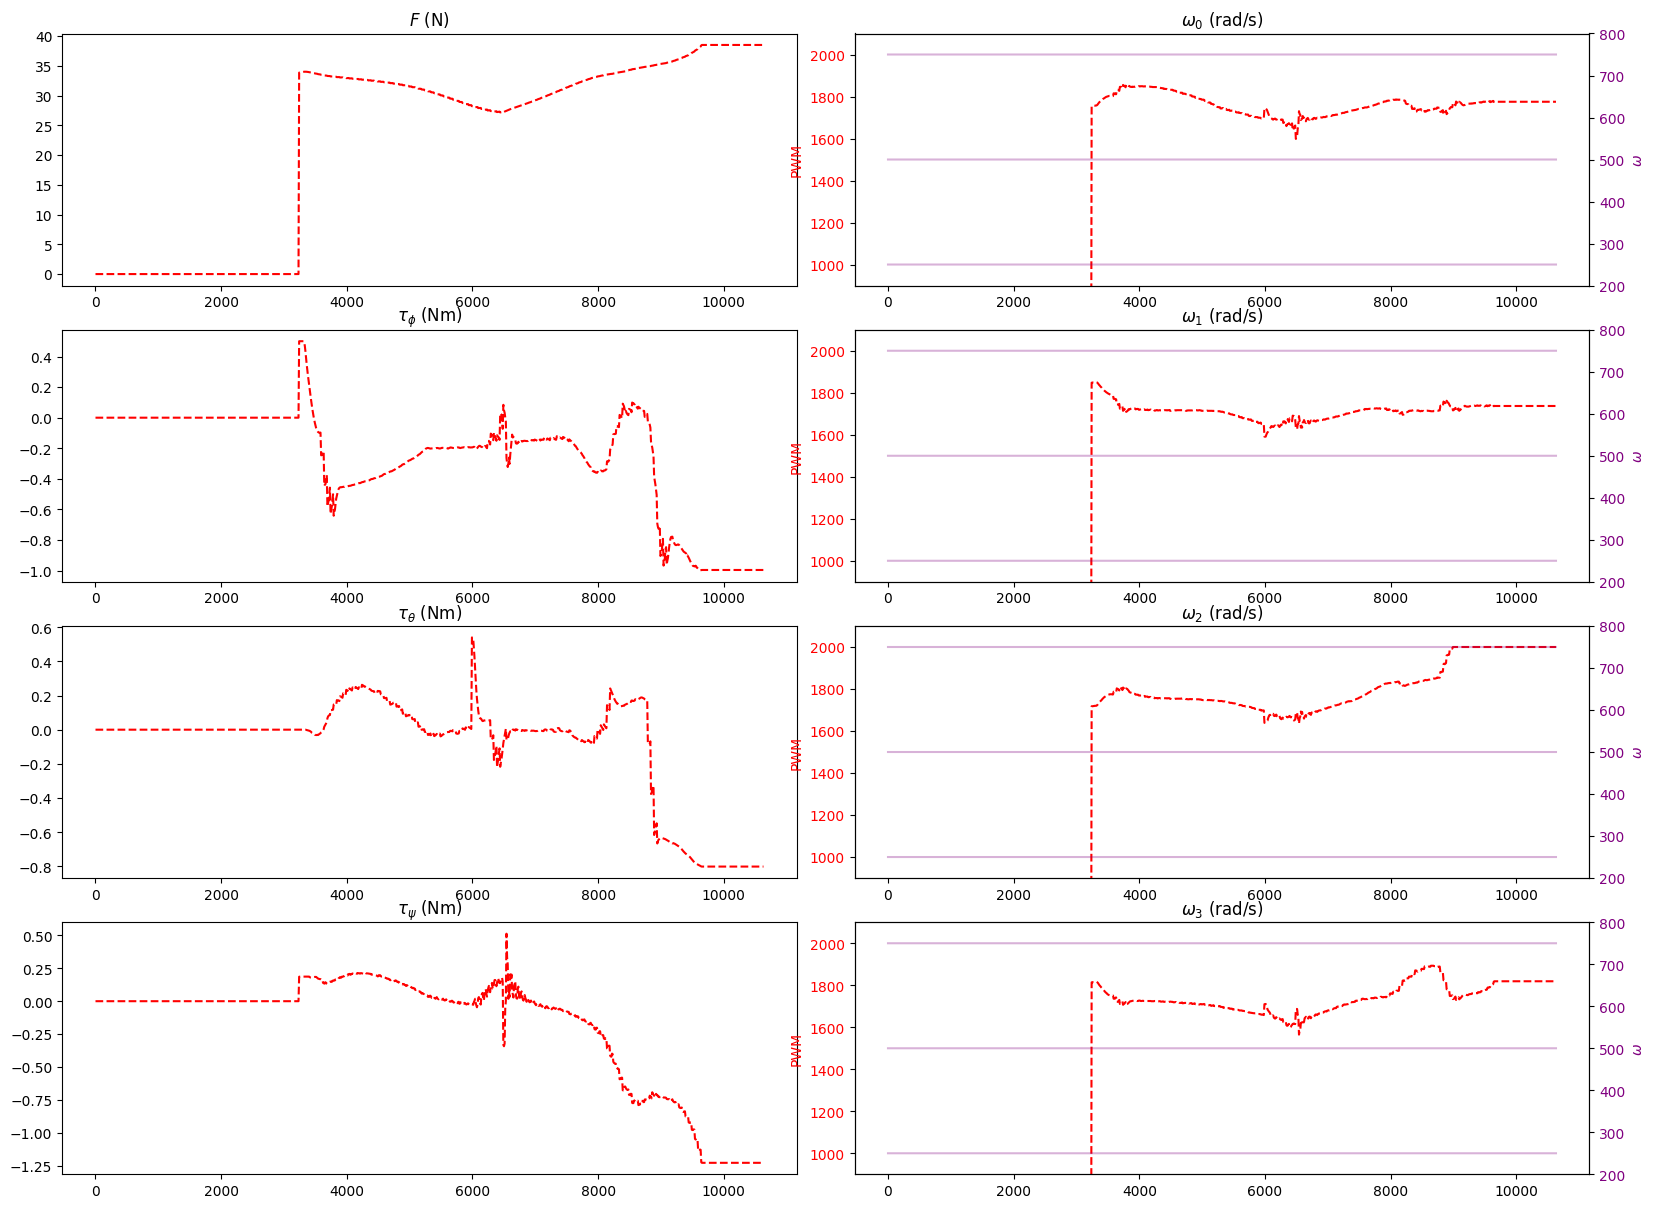

In [7]:
## Control Plots
control_fig, control_ax = plt.subplots(4,2, figsize=(16,12))
control_fig.tight_layout()

control_locs = {
              'force': (0,0,r"$F$ (N)"), 
              'rt': (1,0,r"$\tau_{\phi}$ (Nm)"),
              'pt': (2,0,r"$\tau_{\theta}$ (Nm)"),
              'yt': (3,0,r"$\tau_{\psi}$ (Nm)"),
              'm0': (0,1,r"$\omega_{0}$ (rad/s)"),
              'm1': (1,1,r"$\omega_{1}$ (rad/s)"),
              'm2': (2,1,r"$\omega_{2}$ (rad/s)"),
              'm3': (3,1,r"$\omega_{3}$ (rad/s)")}

for e in control_locs.keys():
    dlen = max_iter if max_iter is not None else len(mc_y[e])

    control_ax[control_locs[e][0], control_locs[e][1]].set_title(control_locs[e][2])    
    control_ax[control_locs[e][0], control_locs[e][1]].plot(mc_x[e][:dlen], mc_y[e][:dlen], linestyle='--', color='red')

    if e in ['m0','m1','m2','m3']:
        control_ax[control_locs[e][0], control_locs[e][1]].set_ylim(900,2100)
        control_ax[control_locs[e][0], control_locs[e][1]].tick_params(axis='y', labelcolor='red')
        control_ax[control_locs[e][0], control_locs[e][1]].set_ylabel("PWM", color='red')

        cax_2 = control_ax[control_locs[e][0], control_locs[e][1]].twinx()
        cax_2.set_ylim(200,800)
        cax_2.set_ylabel(r"$\omega$", color='purple')
        cax_2.tick_params(axis='y', labelcolor='purple')

        for row in [250, 500, 750]:
            cax_2.plot(mc_x[e][:dlen], dlen*[row], color='purple', alpha=0.3)
        
plt.show()

[0, 0, 0, 0, 0, 11, 21, 31, 41, 51]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.26272639632225037, 0.25928136706352234, 0.2596985101699829, 0.26106467843055725, 0.26108255982398987]
1068


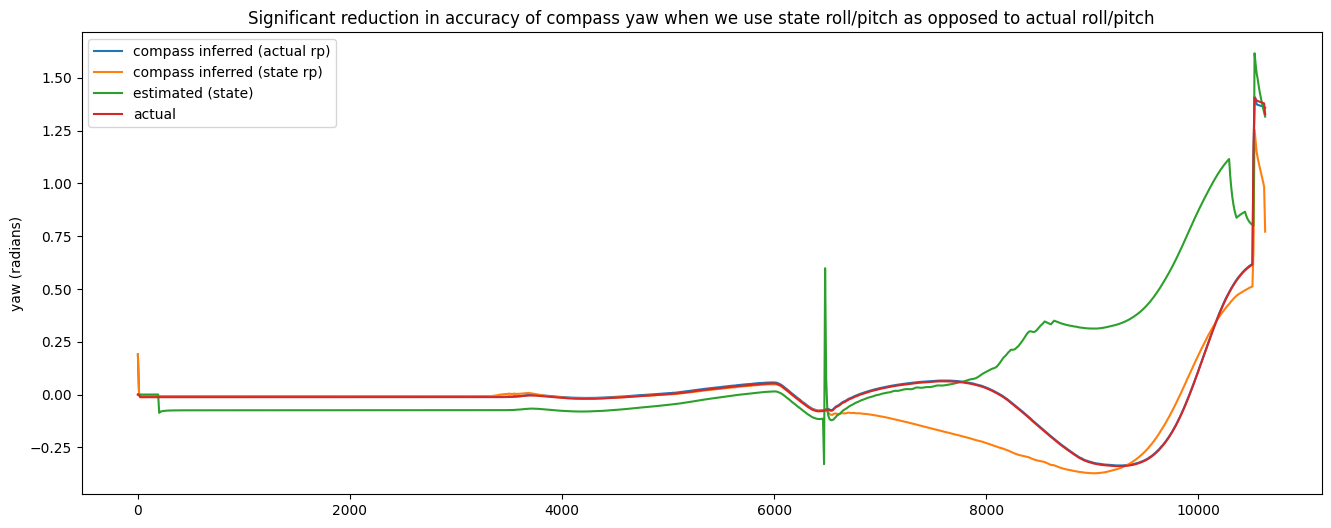

In [8]:
### Inferred Compass Heading
print(mc_x['comp_x'][:10])
print(mc_y['comp_x'][:10])
print(len(mc_x['comp_x']))
'''roll, pitch, yaw, comp_x, comp_y, comp_z'''

m_norm = [math.sqrt(mc_y['comp_x'][i]**2 + mc_y['comp_y'][i]**2 + mc_y['comp_z'][i]**2) for i in range(0,len(mc_x['comp_x']))]

mx_est = [e / n if n != 0 else 0 for e,n in zip(mc_y['comp_x'], m_norm)]
my_est = [e / n if n != 0 else 0 for e,n in zip(mc_y['comp_y'], m_norm)]
mz_est = [e / n if n != 0 else 0 for e,n in zip(mc_y['comp_z'], m_norm)]

yaw_mag_est_rp = [0.19+
    math.atan2(-1*my_est[i]*math.cos(mc_y['roll'][i]) + mz_est[i]*math.sin(mc_y['roll'][i]),
                    mx_est[i]*math.cos(mc_y['pitch'][i]) + my_est[i]*math.sin(mc_y['pitch'][i])*math.sin(mc_y['roll'][i])
                   + mz_est[i]*math.sin(mc_y['pitch'][i])*math.cos(mc_y['roll'][i])) for i in range(0,len(mc_x['comp_x']))
    ]

yaw_mag_actual_rp = [0.19+
        math.atan2(-1*my_est[i]*math.cos(mc_y['eul_x_a'][i]) + mz_est[i]*math.sin(mc_y['eul_x_a'][i]),
                    mx_est[i]*math.cos(mc_y['eul_y_a'][i]) + my_est[i]*math.sin(mc_y['eul_y_a'][i])*math.sin(mc_y['eul_x_a'][i])
                   + mz_est[i]*math.sin(mc_y['eul_y_a'][i])*math.cos(mc_y['eul_x_a'][i])) for i in range(0,len(mc_x['comp_x']))
    ]
    
fig, ax = plt.subplots(1,1,figsize=(16,6))
plt.plot(mc_x['comp_x'], yaw_mag_actual_rp, label='compass inferred (actual rp)')
plt.plot(mc_x['comp_x'], yaw_mag_est_rp, label='compass inferred (state rp)')
plt.plot(mc_x['comp_x'], mc_y['yaw'], label='estimated (state)')
plt.plot(mc_x['comp_x'], mc_y['eul_z_a'], label='actual')
plt.legend()
plt.ylabel('yaw (radians)')
plt.title('Significant reduction in accuracy of compass yaw when we use state roll/pitch as opposed to actual roll/pitch')
plt.show()

In [9]:
'''
GPS pos/vel est: (0.233772,-0.098506,-8.720000), (0.040000,17.47000,0.160000)
State est      : (0.087382,7.109784,-9.014402), (-0.046706,1.789116,-0.063553)
Home                      : -353632619, 1491652370, 0
lat/lng           : -353632598, 1491668971
'''

lat_off = (-353632598 + 353632619 ) / 1e7
lng_off = (1491668971 - 1491652370) / 1e7
print(lat_off, lng_off)

gps_north_pos = lat_off*111320
gps_east_pos = lng_off*40075000 * math.cos(math.pi * (-353632598/1e7) / 180) / 360
print(gps_north_pos, gps_east_pos)

2.1e-06 0.0016601
0.23377199999999998 150.70538051764026


In [10]:
mc_y['gyro_x'][0:100]

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.3824358880519867,
 0.8404962420463562,
 -0.0004422591009642929,
 0.00018624975928105414,
 5.305681042955257e-05,
 0.0001515443727839738,
 0.00013703189324587584,
 0.00012393663928378373,
 0.00011208489740965888,
 0.00010136755736311898,
 9.167505049845204e-05,
 8.290930418297648e-05,
 7.498164632124826e-05,
 6.78120122756809e-05,
 6.132798444014043e-05,
 5.546397733269259e-05,
 5.0160630053142086e-05,
 4.536432243185118e-05,
 4.1026654798770323e-05,
 3.710381861310452e-05,
 3.3556061680428684e-05,
 3.0347473511938006e-05,
 2.7445661544334143e-05,
 2.4821367333061062e-05,
 2.2448057279689237e-05,
 2.0301627955632284e-05,
 1.8360380636295304e-05,
 1.6604768461547792e-05,
 1.4866901437926572e-05,
 1.3581230632553343e-05,
 1.2282597708690446e-05,
 1.1108116268587764e-05,
 1.004597834253218e-05,
 9.085452802537475e-06,
 8.216745300160255e-06,
 7.4310250965936575e-06,
 6.720455075992504e-06,
 6.077885245758807e-06,
 5.49678679817589e-06,
 4.971174348611385e-0